<a href="https://colab.research.google.com/github/VarshaNeelvani/InnomaticsInternship/blob/main/NLP_Preprocessing_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Task 1: Conceptual Understanding (Mandatory – Written)**

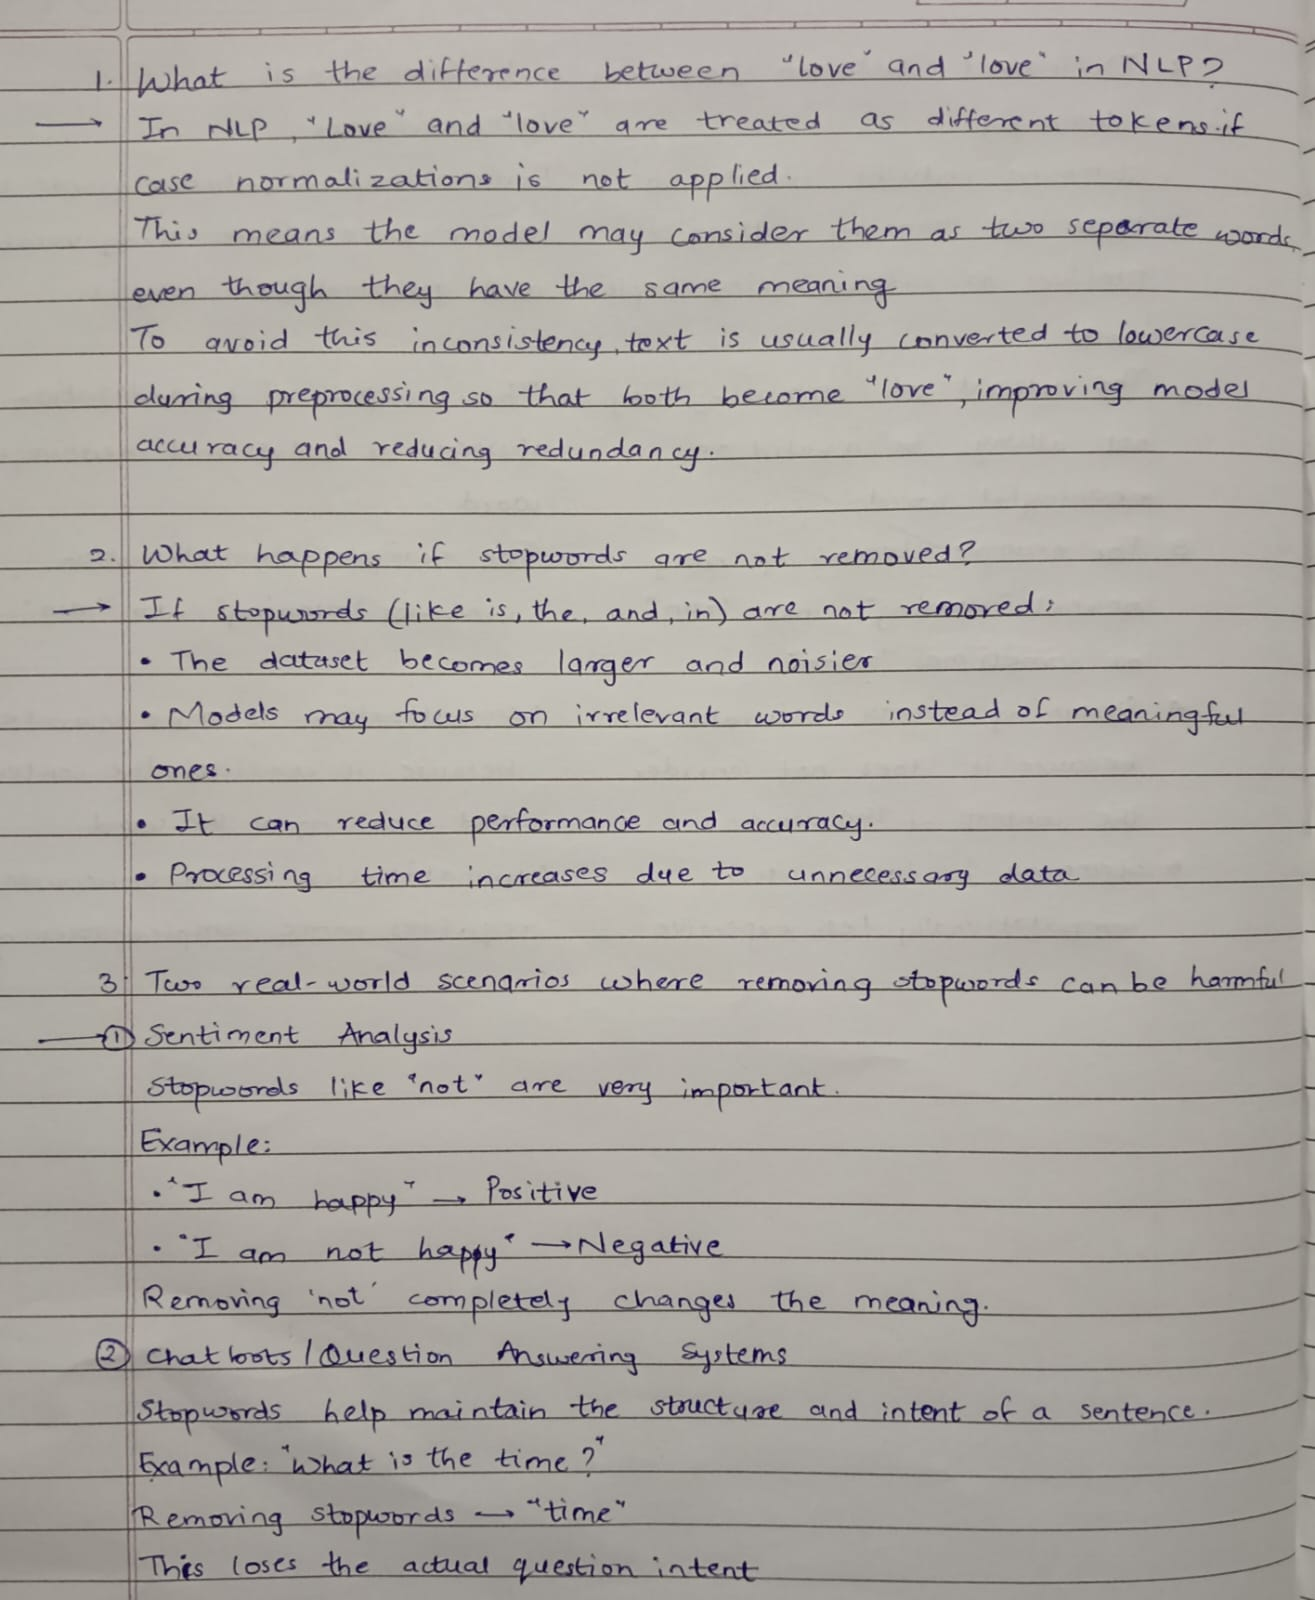

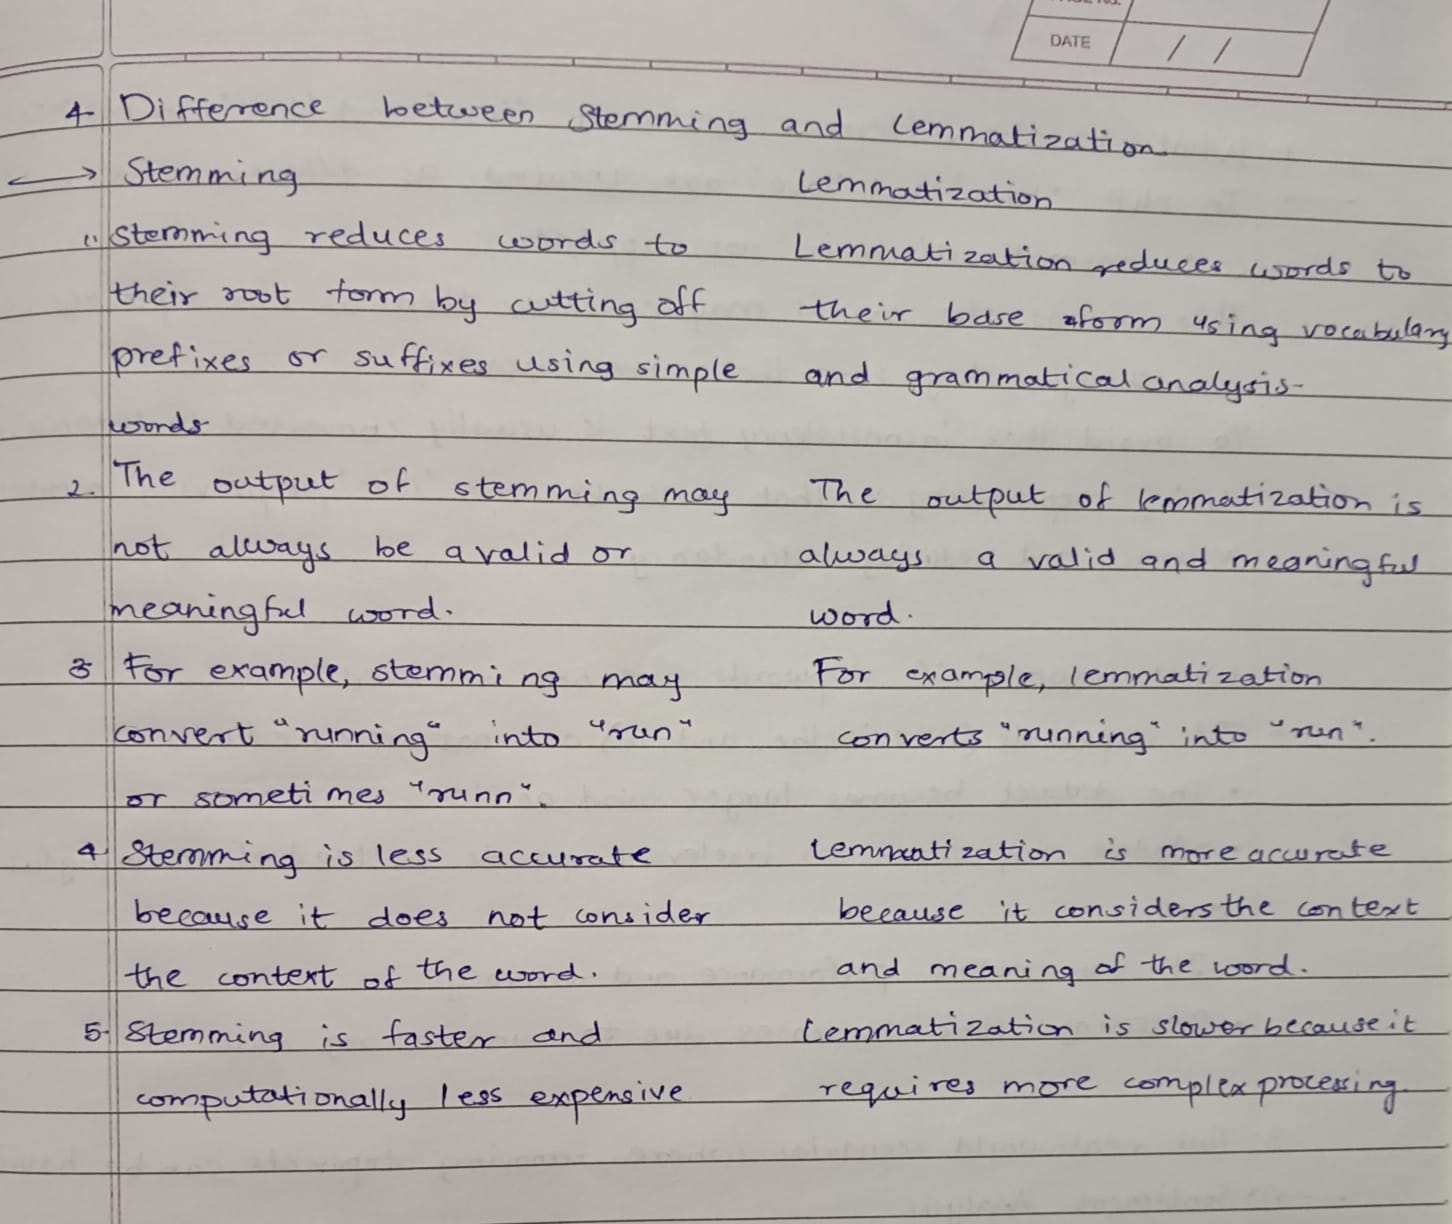

## **Task 2: Build Advanced Preprocessing Function**

In [1]:
import re

def preprocess_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return []

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'(.)\1{2,}', r'\1', text)

    text = re.sub(r'[^a-z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    cleaned_tokens = []
    for word in tokens:
        if len(word) > 2 or word in ["no", "not"]:
            cleaned_tokens.append(word)

    return cleaned_tokens

## **Task 3: Stress Testing**

In [2]:
test_sentences = [
    "Get 100% FREE access now!!!",
    "I absolutely looooved this product 😍😍",
    "Worst service ever... 0/10",
    "Call me at 9876543210",
    "This is THE best course!!!",
    "Visit https://example.com now!",
    "Nooooo this is baaad!!!",
    "OK OK OK I got it",
    "Win $$$ now!!! Limited offer!!!",
    "I am not happy with this"
]

for sentence in test_sentences:
    tokens = preprocess_text(sentence)
    cleaned_sentence = " ".join(tokens)

    print("Original Text:", sentence)
    print("Cleaned Tokens:", tokens)
    print("Cleaned Sentence:", cleaned_sentence)
    print("-" * 50)

Original Text: Get 100% FREE access now!!!
Cleaned Tokens: ['get', 'free', 'access', 'now']
Cleaned Sentence: get free access now
--------------------------------------------------
Original Text: I absolutely looooved this product 😍😍
Cleaned Tokens: ['absolutely', 'loved', 'this', 'product']
Cleaned Sentence: absolutely loved this product
--------------------------------------------------
Original Text: Worst service ever... 0/10
Cleaned Tokens: ['worst', 'service', 'ever']
Cleaned Sentence: worst service ever
--------------------------------------------------
Original Text: Call me at 9876543210
Cleaned Tokens: ['call']
Cleaned Sentence: call
--------------------------------------------------
Original Text: This is THE best course!!!
Cleaned Tokens: ['this', 'the', 'best', 'course']
Cleaned Sentence: this the best course
--------------------------------------------------
Original Text: Visit https://example.com now!
Cleaned Tokens: ['visit', 'now']
Cleaned Sentence: visit now
--------

## **Task 4: Token Analytics**

In [3]:
def token_analytics(tokens):
    if not tokens:
        return 0, 0, 0

    total_tokens = len(tokens)
    unique_tokens = len(set(tokens))
    avg_length = sum(len(word) for word in tokens) / total_tokens

    return total_tokens, unique_tokens, round(avg_length, 2)


for sentence in test_sentences:
    tokens = preprocess_text(sentence)
    total, unique, avg_len = token_analytics(tokens)

    print("Sentence:", sentence)
    print("Tokens:", tokens)
    print("Total Tokens:", total)
    print("Unique Tokens:", unique)
    print("Average Token Length:", avg_len)
    print("-" * 50)

Sentence: Get 100% FREE access now!!!
Tokens: ['get', 'free', 'access', 'now']
Total Tokens: 4
Unique Tokens: 4
Average Token Length: 4.0
--------------------------------------------------
Sentence: I absolutely looooved this product 😍😍
Tokens: ['absolutely', 'loved', 'this', 'product']
Total Tokens: 4
Unique Tokens: 4
Average Token Length: 6.5
--------------------------------------------------
Sentence: Worst service ever... 0/10
Tokens: ['worst', 'service', 'ever']
Total Tokens: 3
Unique Tokens: 3
Average Token Length: 5.33
--------------------------------------------------
Sentence: Call me at 9876543210
Tokens: ['call']
Total Tokens: 1
Unique Tokens: 1
Average Token Length: 4.0
--------------------------------------------------
Sentence: This is THE best course!!!
Tokens: ['this', 'the', 'best', 'course']
Total Tokens: 4
Unique Tokens: 4
Average Token Length: 4.25
--------------------------------------------------
Sentence: Visit https://example.com now!
Tokens: ['visit', 'now']
To

**1. Which sentence had the most noise?**

The sentence "Get 100% FREE access now!!!" had the most noise because it contained numbers, symbols, uppercase text, and punctuation, all of which were removed during preprocessing.

**2. Which sentence retained the most meaningful tokens after cleaning?**

The sentence "I absolutely looooved this product 😍😍" retained the most meaningful tokens after cleaning because, despite having emojis and repeated characters, it preserved important words like "absolutely", "loved", and "product".

## **Task 5: Frequency Analysis**

In [4]:
from collections import Counter

all_tokens = []

for sentence in test_sentences:
    tokens = preprocess_text(sentence)
    all_tokens.extend(tokens)

word_freq = Counter(all_tokens)

top_10 = word_freq.most_common(10)

least_5 = word_freq.most_common()[:-6:-1]

print("Top 10 Most Frequent Words:")
for word, freq in top_10:
    print(word, ":", freq)

print("\nTop 5 Least Frequent Words:")
for word, freq in least_5:
    print(word, ":", freq)

Top 10 Most Frequent Words:
this : 4
now : 3
get : 1
free : 1
access : 1
absolutely : 1
loved : 1
product : 1
worst : 1
service : 1

Top 5 Least Frequent Words:
with : 1
happy : 1
not : 1
offer : 1
limited : 1


## **Task 6: Build Full Pipeline**

In [5]:
def full_pipeline(text_list):
    if not isinstance(text_list, list):
        return {"tokens": [], "clean_sentences": []}

    all_tokens = []
    clean_sentences = []

    for text in text_list:
        tokens = preprocess_text(text)
        all_tokens.extend(tokens)
        clean_sentences.append(" ".join(tokens))

    return {
        "tokens": all_tokens,
        "clean_sentences": clean_sentences
    }

In [6]:
result = full_pipeline(test_sentences)

print("All Tokens:", result["tokens"])
print("\nClean Sentences:")
for sentence in result["clean_sentences"]:
    print(sentence)

All Tokens: ['get', 'free', 'access', 'now', 'absolutely', 'loved', 'this', 'product', 'worst', 'service', 'ever', 'call', 'this', 'the', 'best', 'course', 'visit', 'now', 'no', 'this', 'bad', 'got', 'win', 'now', 'limited', 'offer', 'not', 'happy', 'with', 'this']

Clean Sentences:
get free access now
absolutely loved this product
worst service ever
call
this the best course
visit now
no this bad
got
win now limited offer
not happy with this


## **Task 7: Error Handling**

In [7]:
import re

def preprocess_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return []

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'(.)\1{2,}', r'\1', text)

    text = re.sub(r'[^a-z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    if text == "":
        return []

    tokens = text.split()

    cleaned_tokens = []
    for word in tokens:
        if len(word) > 2 or word in ["no", "not"]:
            cleaned_tokens.append(word)

    return cleaned_tokens

In [8]:
edge_cases = [
    "",
    "😂😂😂",
    "123456789",
    "   ",
]

for case in edge_cases:
    print("Input:", repr(case))
    print("Output:", preprocess_text(case))
    print("-" * 30)

Input: ''
Output: []
------------------------------
Input: '😂😂😂'
Output: []
------------------------------
Input: '123456789'
Output: []
------------------------------
Input: '   '
Output: []
------------------------------
